# IOAI — 2025 At Home Round Chameleon — ⭐모범답안 (Colab 자동 설정판)

이 노트북은 IOAI 로컬 연습 사이트에서 **데이터·학습환경이 자동 준비**되도록 생성되었습니다.
아래 **설정 셀을 먼저 실행**하면 공식 GitHub 저장소에서 이 문제 폴더만 부분 클론으로 받아
(전체 6.6GB 가 아니라 해당 폴더만), 그 폴더로 이동한 뒤 이후 셀이 그대로 학습/예측을 합니다.
완료 후 생성되는 제출 파일을 내려받아 연습 사이트의 **Submissions** 탭에 올리면 채점됩니다.

> 런타임 메뉴 → **런타임 유형 변경 → GPU** 로 바꾸면 학습이 빨라집니다.

In [26]:
# === 데이터 + 환경 자동 설정 (가장 먼저 실행) ===
# 공식 공개 저장소에서 이 문제 폴더만 부분 클론(sparse)으로 받고 그 폴더로 이동한다.
import os
REPO_URL = "https://github.com/IOAI-official/IOAI-2025"
CLONE = "IOAI-2025"
SUBDIR = "At-Home-Round/Chameleon"
WORKDIR = "At-Home-Round/Chameleon"
# Colab 은 /content 가 홈. 재실행해도 경로가 안정적이도록 고정 기준에서 시작한다.
BASE = "/content" if os.path.isdir("/content") else os.getcwd()
os.chdir(BASE)
if not os.path.isdir(os.path.join(CLONE, SUBDIR)):
    !git clone --filter=blob:none --no-checkout --depth 1 $REPO_URL $CLONE
    !cd $CLONE && git sparse-checkout set "$SUBDIR"
    !cd $CLONE && git checkout
os.chdir(os.path.join(BASE, CLONE, WORKDIR))
# 대회 requirements.txt 의 관련 라이브러리 버전으로 정렬하는 constraints(아래 pip 에 적용)
CONSTRAINTS = r'''# IOAI-2025 대회 requirements.txt 에서 추출한 큐레이션 constraints — Colab (과학 패키지 unpin — 세션 numpy 충돌 방지, ML 프레임워크는 대회 핀).
# torch/vllm/xformers/nvidia-cu12 는 제외(환경별 별도 관리).
# 생성: python -m ioai_env constraints
accelerate==1.8.1
bitsandbytes==0.46.1
datasets==3.6.0
einops==0.8.1
ftfy==6.3.1
hf-xet==1.1.5
hf_transfer==0.1.9
huggingface-hub==0.34.2
ipykernel==6.29.5
ipywidgets==7.8.5
jupyter_client==8.6.3
jupyter_core==5.7.2
jupyter_server==2.15.0
jupyterlab==4.3.4
msgspec==0.19.0
notebook==7.3.2
openai==1.90.0
peft==0.16.0
protobuf==5.28.3
pydantic==2.10.3
regex==2024.11.6
safetensors==0.5.3
sentence-transformers==4.1.0
sentencepiece==0.2.0
timm==1.0.16
tokenizers==0.21.2
tqdm==4.67.1
traitlets==5.14.3
transformers==4.54.0
trl==0.19.1
tyro==0.9.26
unsloth==2025.7.8
unsloth_zoo==2025.7.10
'''
open('/content/ioai-constraints.txt', 'w').write(CONSTRAINTS)
!pip install -q -c /content/ioai-constraints.txt sentence-transformers
print("작업 폴더:", os.getcwd())
print("내용:", sorted(os.listdir(".")))

작업 폴더: /content/IOAI-2025/At-Home-Round/Chameleon
내용: ['Chameleon.ipynb', 'Chameleon_Solution.ipynb', 'checkpoints', 'figs', 'metrics.py', 'model', 'submission.zip', 'submission_model.py', 'test_set', 'training_set', 'validation_set']


<img src="https://github.com/scvcoder/ioai-colab/blob/main/notebooks/figs/IOAI-Logo.png?raw=1" alt="IOAI Logo" width="200" height="auto">

[IOAI 2025 (Beijing, China), At-Home Round](https://ioai-official.org/china-2025)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/IOAI-official/IOAI-2025/blob/main/At-Home-Round/Chameleon/Chameleon_Solution.ipynb)

## Data Loading

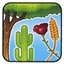

Flora
Plant
Nature


In [27]:
from IPython.display import display
from PIL import Image
from datasets import Dataset
TRAIN_TEXT = "."
hint_description = Dataset.load_from_disk(TRAIN_TEXT + "/training_set/hint_descriptions")
hint_description = {
    x['ID']: {'description': x['Description'], 'icons': x['image']}
    for x in hint_description
}

# show example
display(hint_description[7]['icons'])
print(hint_description[7]['description'])

In [28]:
from torch.utils.data import random_split
import torch, random
SEED = 42; random.seed(SEED); torch.manual_seed(SEED)

full = Dataset.load_from_disk(TRAIN_TEXT + "/training_set/takehome_validation")
n = len(full); v = max(1, int(n * 0.15))
train_data, val_data = random_split(full, [n - v, v], generator=torch.Generator().manual_seed(SEED))
print("train/val:", len(train_data), len(val_data))   # train_data=학습, val_data=홀드아웃

train/val: 17 3


## Implement keyword guesser

Internet access is allowed in Bohrium, so contestants could download pre-trained models from huggingface. However, since the servers are hosted on mainland China, they are subject to internet restrictions that blocks access to sources like huggingface. To circumvent this, we can use hosted mirror servers(which we'll also provide at the on-site round). For huggingface, you can set os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'  to use a huggingface mirror that's accessible from Bohrium's server.

In [29]:
import os
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

In [30]:
import logging; logging.basicConfig(level=logging.INFO)
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('sentence-t5-large')   # <1B. 가장 안전한 대안: 'all-MiniLM-L6-v2'(베이스라인 검증됨)
print("dim:", model.get_sentence_embedding_dimension())

dim: 768


In [31]:
def hints_to_sentence(hints):
    s = "The following hints at our target word:\n<HINT_PRIMARY>\n"
    for i, h in enumerate(hints):
        s += f"{hint_description[h]['description']}"
        s += "\n</HINT_PRIMARY>\n<HINT>\n" if i == 0 else ("\n</HINT>\n<HINT>\n" if i < len(hints)-1 else "\n</HINT>")
    return s

def choice_to_doc(choice):     # 추론이 raw choices를 인코딩하므로 학습 문서도 맨단어
    return f"{choice}"

In [32]:
from sentence_transformers import InputExample, losses
from torch.utils.data import DataLoader
import os, random, math, numpy as np
os.environ["WANDB_DISABLED"] = "true"

# --- 실제 대회 지표로 평가하는 헬퍼 (붕괴/과적합을 점수로 직접 감시) ---
def _rank(m, hints, choices, k=10):
    q = m.encode([hints_to_sentence(hints)])
    sim = cosine_similarity(q, m.encode(choices))[0]
    return [choices[i] for i in np.argsort(sim)[::-1][:k]]

def _score(guesses, gold):
    gl = [g.lower() for g in guesses[:10]]; gold = gold.lower()
    if gold in gl:
        r = gl.index(gold); return 0.9 + 0.1 * (1/math.log2(r+2))
    return 0.0

def eval_score(m):
    return sum(_score(_rank(m, e['hints'], e['options']), e['label']) for e in val_data) / len(val_data)

# --- 학습쌍: (힌트문장, 정답) + 같은 게임 options에서 뽑은 '하드 네거티브' ---
NEG_PER_GAME = 4
train_examples = []
for g in train_data:
    anchor = hints_to_sentence(g['hints']); pos = choice_to_doc(g['label'])
    negs = [o for o in g['options'] if o.lower() != g['label'].lower()]
    for neg in random.sample(negs, min(NEG_PER_GAME, len(negs))):
        train_examples.append(InputExample(texts=[anchor, pos, choice_to_doc(neg)]))  # [anchor, +, hard-]
print("train triplets:", len(train_examples))

train_loss = losses.MultipleNegativesRankingLoss(model)   # in-batch + 하드 네거티브 → 붕괴 방지

best = -1.0
for ep in range(15):                                       # MNRL은 빨리 수렴, 지표로 best만 보관
    loader = DataLoader(train_examples, shuffle=True, batch_size=32)   # 배치 클수록 음성 풍부
    model.fit([(loader, train_loss)], epochs=1,
              warmup_steps=max(1, int(0.1*len(loader))),
              optimizer_params={'lr': 2e-5},              # 베이스라인 1e-6은 너무 낮았음
              weight_decay=0.01, use_amp=False, show_progress_bar=False)
    s = eval_score(model)
    print(f"epoch {ep+1}/15: val {s:.4f}" + ("  ✅ best" if s > best else ""))
    if s > best: best = s; model.save('./model')
print("best val score:", round(best, 4))
ft_model_loaded = SentenceTransformer('./model')

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


train triplets: 68


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

{'train_runtime': 1.9514, 'train_samples_per_second': 34.847, 'train_steps_per_second': 1.537, 'train_loss': 2.86904239654541, 'epoch': 1.0}
epoch 1/15: val 0.6500  ✅ best


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


...

epoch 12/15: val 0.9877
{'train_runtime': 1.9248, 'train_samples_per_second': 35.328, 'train_steps_per_second': 1.559, 'train_loss': 1.4539828300476074, 'epoch': 1.0}
epoch 13/15: val 1.0000  ✅ best


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


{'train_runtime': 1.9712, 'train_samples_per_second': 34.497, 'train_steps_per_second': 1.522, 'train_loss': 1.3914601008097331, 'epoch': 1.0}


Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


epoch 14/15: val 1.0000
{'train_runtime': 1.9442, 'train_samples_per_second': 34.976, 'train_steps_per_second': 1.543, 'train_loss': 1.3339195251464844, 'epoch': 1.0}
epoch 15/15: val 1.0000
best val score: 1.0


In [33]:
ft_model_loaded = SentenceTransformer("./model") # Load fine-tuned model

def find_most_similar(query, sentences, model, top_k=10):
    # Encode query and sentences
    query_embedding = model.encode([query])
    sentence_embeddings = model.encode(sentences)

    # Calculate similarities
    similarities = cosine_similarity(query_embedding, sentence_embeddings)[0]

    # Get top-k most similar
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = []
    for idx in top_indices:
        results.append({
            'sentence': sentences[idx],
            'similarity': similarities[idx]
        })

    return results

def guess_words(hints: list[int], choices: list[str]) -> list[str]:
    query = hints_to_sentence(hints)
    results = find_most_similar(query, choices, ft_model_loaded)
    return [result['sentence'] for result in results]

In [34]:
import math

def score(guesses: list[str], gold: str):
    # Normalize to lowercase
    guesses = [g.lower() for g in guesses[:10]]
    gold = gold.lower()

    result = {
        "hits@10": 0.0,
        "ndcg@10": 0.0,
        "total_score": 0.0
    }

    if gold in guesses:
        rank = guesses.index(gold)
        result["hits@10"] = 1.0
        result["ndcg@10"] = 1.0 / math.log2(rank + 2)  # rank + 2 because index is 0-based
    else:
        result["hits@10"] = 0.0
        result["ndcg@10"] = 0.0

    result["total_score"] = 0.9 * result["hits@10"] + 0.1 * result["ndcg@10"]
    return result

print(score(['cat', 'dog', 'tree', 'flower', 'rock', 'water', 'fried rice', 'airplane', 'cactus', 'tiger'], gold='cactus'))

{'hits@10': 1.0, 'ndcg@10': 0.3010299956639812, 'total_score': 0.9301029995663982}


## Model Submission

In [35]:
model_code = '''
from sentence_transformers import SentenceTransformer
from datasets import Dataset
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

TRAIN_TEXT = "."
hint_description = Dataset.load_from_disk(TRAIN_TEXT + "/training_set/hint_descriptions")
hint_description = {x["ID"]: {"description": x["Description"], "icons": x["image"]} for x in hint_description}

model = SentenceTransformer("./model")

def hints_to_sentence(hints):
    s = "The following hints at our target word:\\n<HINT_PRIMARY>\\n"
    for i, h in enumerate(hints):
        s += f"{hint_description[h]['description']}"
        s += "\\n</HINT_PRIMARY>\\n<HINT>\\n" if i == 0 else ("\\n</HINT>\\n<HINT>\\n" if i < len(hints)-1 else "\\n</HINT>")
    return s

def guess_words(hints, choices):
    q = model.encode([hints_to_sentence(hints)])
    sim = cosine_similarity(q, model.encode(choices))[0]
    return [choices[i] for i in np.argsort(sim)[::-1][:10]]
'''
with open("submission_model.py", "w") as f:
    f.write(model_code)
print("submission_model.py written")

submission_model.py written


In [37]:
import shutil
import os
import tempfile

# Create a temporary directory with your desired structure
with tempfile.TemporaryDirectory() as temp_dir:
    # Copy files to temp directory
    shutil.copy('submission_model.py', temp_dir)
    shutil.copytree('./model', os.path.join(temp_dir, 'model'))

    # Create the zip
    shutil.make_archive('submission', 'zip', temp_dir)

## 제출 파일 모으기
아래 셀을 실행하면 제출 파일이 **최상위(`/content`)로 복사**되어 왼쪽 파일 탐색기에 바로 보입니다.
그 파일을 내려받아 연습 사이트 **Submissions** 탭에 올리면 채점됩니다.

In [38]:
# === 제출 파일을 /content 로 모으기 (마지막에 실행) ===
import os, glob, shutil
TARGETS = ['submission.zip']
OUT = "/content" if os.path.isdir("/content") else os.getcwd()
found = []
for name in TARGETS:
    hits = [name] if os.path.exists(name) else glob.glob(f"**/{name}", recursive=True)
    if not hits:
        print("아직 없음(해당 셀을 먼저 실행하세요):", name); continue
    dst = os.path.join(OUT, os.path.basename(hits[0]))
    if os.path.abspath(hits[0]) != os.path.abspath(dst):
        shutil.copy2(hits[0], dst)
    found.append(dst)
print("제출 파일 저장 위치(파일 탐색기 최상위):", found)

제출 파일 저장 위치(파일 탐색기 최상위): ['/content/submission.zip']
